In [1]:
%reload_ext autoreload
%autoreload 2

# Timeout Impact Research

Answers the README questions on cdnnba play-by-play (2020-2025).

1. **Short-term point differential** — pts in 6 possessions after a timeout vs 6 before, compared to (a) each team's season PPP and (b) season-long head-to-head differential per possession.
2. **Short-term momentum (PPP)** — points-per-possession after vs before, compared to the calling team's season PPP.
3. **Long-term — WP added** — change in home win-probability across the timeout window, signed from the calling team's perspective. WP model is a logistic regression on `(score_margin, period, seconds_remaining, is_clutch, poss_is_home, streak, IsPlayoff, home_wpct, away_wpct, wpct_diff)` trained on possession-start snapshots.

Each cell calls into `nba_timeout_impact.analyses.{timeout_impact, wp_model}` — the heavy logic lives there so this notebook stays readable.

## Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_polars._core.polars_nb_imports import *

from nba_timeout_impact.nb_imports import *

from nba_timeout_impact.analyses.timeout_impact import (
    add_context_buckets,
    attach_baselines,
    build_timeout_events,
    compute_h2h_pt_diff,
    compute_team_season_ppp,
    compute_team_season_record,
    summarize_overall_table,
    summarize_pre_post,
)
from nba_timeout_impact.analyses.wp_model import (
    WP_FEATURES,
    build_wp_dataset,
    coef_table,
    compute_wp_added,
    evaluate_wp_model,
    summarize_wp_added,
    train_wp_model,
)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.1098 seconds


## Load Data

In [3]:
memo = CDNNBAMemoPL.load_all()

  Injected 14,561 inferred TV timeouts (rulebook) across 6,989 games (2.1/game)
Validating cdnnba data (Polars)...
  Passed (4,183,347 rows, 74 cols, 2 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


## Season Baselines

- `team_ppp` — per-team season points-per-possession.
- `h2h` — for each season-by-season ordered (calling, opponent) team pair, the point differential per possession across all matchups.
- `records` — final regular-season W-L per team (used as a feature in the WP model).

In [4]:
team_ppp = compute_team_season_ppp(memo)
h2h = compute_h2h_pt_diff(memo)
records = compute_team_season_record(memo)

print(f"team_ppp:  {team_ppp.shape}")
print(f"h2h:       {h2h.shape}")
print(f"records:   {records.shape}")
team_ppp.describe()

Computing possessions table...
Calculating streak
  1,480,697 possessions
team_ppp:  (260, 6)
h2h:       (5364, 8)
records:   (180, 5)


statistic,season,season_type,teamId,total_pts,n_poss,ppp
str,f64,str,f64,f64,f64,f64
"""count""",260.0,"""260""",260.0,260.0,260.0,260.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""",2022.346154,null,1.6106e9,6489.85,5694.988462,1.132643
"""std""",1.642634,null,8.435066,3637.864346,3179.38115,0.046553
"""min""",2020.0,"""po""",1.6106e9,360.0,357.0,0.944444
"""25%""",2021.0,null,1.6106e9,1914.0,1682.0,1.106918
"""50%""",2022.0,null,1.6106e9,8291.0,7232.0,1.14318
"""75%""",2024.0,null,1.6106e9,9274.0,8109.0,1.163482
"""max""",2025.0,"""rg""",1.6106e9,10109.0,8478.0,1.228833


## Build the Timeout Events Table

One row per timeout. Window = 6 possessions per side (3 per team). Computes pre/post pts + PPP from the calling team's perspective, attaches season baselines, and tags context buckets.

In [5]:
WINDOW = 6
events = build_timeout_events(memo, window=WINDOW)
events = attach_baselines(events, team_ppp, h2h, window=WINDOW)
print(f"events: {events.shape}")
events.head(3)

events: (90170, 43)


gameId,possession_id,period,game_seconds_elapsed,seconds_remaining,score_margin,season,season_type,IsPlayoff,timeout_subtype,calling_team,is_endogenous,opponent_team,is_home_calling,pts_for_pre,pts_against_pre,pts_for_post,pts_against_post,n_for_pre,n_against_pre,n_for_post,n_against_post,net_pre,net_post,net_change,ppp_for_pre,ppp_against_pre,ppp_for_post,ppp_against_post,streak_signed,time_bucket,margin_calling,margin_bucket,streak_bucket,calling_team_ppp,opponent_team_ppp,h2h_pt_diff_per_poss,expected_net_per_poss,expected_net_window,h2h_expected_net_window,excess_net_post,excess_h2h_net_post,excess_ppp_for_post
i64,i64,i64,f64,f64,i64,i64,str,bool,cat,i64,bool,i64,bool,i64,i64,i64,i64,i32,i32,i32,i32,i64,i64,i64,f64,f64,f64,f64,i64,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
22000001,24,1,280.0,440.0,10,2020,"""rg""",false,"""full""",1610612744,true,1610612751,false,2,5,1,5,3,3,3,3,-3,-4,-1,0.666667,1.666667,0.333333,1.666667,-5,"""Q1""",-10,"""down6-15""","""down3-5""",1.112273,1.18031,-0.099768,-0.068037,-0.204111,-0.299304,-3.795889,-3.700696,-0.778939
22000001,43,1,549.0,171.0,11,2020,"""rg""",false,"""official_inferred""",1610612751,false,1610612744,true,0,4,6,0,3,3,3,3,-4,6,10,0.0,1.333333,2.0,0.0,-4,"""Q1""",11,"""up6-15""","""down3-5""",1.18031,1.112273,0.099768,0.068037,0.204111,0.299304,5.795889,5.700696,0.81969
22000001,43,1,549.0,171.0,11,2020,"""rg""",false,"""full""",1610612751,true,1610612744,true,0,4,6,0,3,3,3,3,-4,6,10,0.0,1.333333,2.0,0.0,-4,"""Q1""",11,"""up6-15""","""down3-5""",1.18031,1.112273,0.099768,0.068037,0.204111,0.299304,5.795889,5.700696,0.81969


In [6]:
# Sanity: counts by subtype and context
events.group_by("timeout_subtype").agg(pl.len().alias("n")).sort("n", descending=True)

timeout_subtype,n
cat,u32
"""full""",74236
"""official_inferred""",14538
"""challenge""",1396


## Q1. Short-term Point Differential

`net_pre` and `net_post` are the calling team's point differential over the W/2 possessions on each side.

- `delta_mean` = mean(`net_post − net_pre`).
- `excess_vs_baseline` = mean(`net_post − (calling_ppp − opp_ppp) × W/2`). Positive = the post-window outperformed the season-long difference between the two teams.
- `excess_vs_h2h` = mean(`net_post − h2h_pt_diff_per_poss × W/2`). Same idea but using the season-long head-to-head differential.

In [7]:
summarize_overall_table(events)

group,n,net_pre_mean,net_post_mean,delta_mean,ppp_for_pre_mean,ppp_for_post_mean,excess_net_post_mean,excess_h2h_net_post_mean,excess_ppp_for_post_mean,t_stat_post_vs_pre,p_value_post_vs_pre
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""all""",90170,-1.501397,-0.015626,1.485771,0.92723,1.146348,-0.01106,-0.008397,0.007377,-104.79095,0.0
"""endogenous (coach)""",75632,-1.727153,-0.017902,1.70925,0.88649,1.145126,-0.012617,-0.009698,0.006219,-110.563663,0.0
"""exogenous (TV/inferred)""",14538,-0.326936,-0.003783,0.323153,1.139175,1.152703,-0.00296,-0.001626,0.013404,-9.52061,1.8506e-21


In [8]:
summarize_pre_post(events, ["timeout_subtype"])

timeout_subtype,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""",1396,0.696275,-0.100287,-0.796562,4.044929,-0.111779,-0.116421,7.163253,1.0045e-12
"""full""",74236,-1.772725,-0.016353,1.756372,4.243269,-0.010753,-0.007691,-112.861981,0.0
"""official_inferred""",14538,-0.326936,-0.003783,0.323153,4.093694,-0.00296,-0.001626,-9.52061,1.8506e-21


In [9]:
summarize_pre_post(events, ["timeout_subtype", "is_home_calling"])

timeout_subtype,is_home_calling,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,bool,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""",false,647,0.621329,-0.185471,-0.806801,4.146103,-0.198397,-0.205092,4.804134,0.000002
"""challenge""",true,749,0.761015,-0.026702,-0.787717,3.958212,-0.036957,-0.039825,5.321127,1.1884e-7
"""full""",false,37014,-1.907548,-0.084319,1.823229,4.235032,-0.079027,-0.075502,-82.976733,0.0
"""full""",true,37222,-1.638655,0.051233,1.689888,4.250458,0.05714,0.059741,-76.758482,0.0
"""official_inferred""",false,7172,-0.343279,-0.074038,0.269241,4.08935,-0.073655,-0.072684,-5.589917,2.3133e-8
"""official_inferred""",true,7366,-0.311024,0.064621,0.375645,4.097515,0.065873,0.06756,-7.854252,4.2987e-15


In [10]:
summarize_pre_post(events, ["timeout_subtype", "IsPlayoff"])

timeout_subtype,IsPlayoff,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,bool,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""",false,1311,0.678871,-0.127384,-0.806255,4.027651,-0.136302,-0.141794,7.040298,2.4427e-12
"""challenge""",true,85,0.964706,0.317647,-0.647059,4.325192,0.266455,0.27492,1.395384,0.164749
"""full""",false,69939,-1.771172,-0.015356,1.755816,4.239653,-0.009831,-0.006529,-109.533879,0.0
"""full""",true,4297,-1.797999,-0.032581,1.765418,4.302178,-0.025747,-0.026616,-27.203387,2.1769e-156
"""official_inferred""",false,13787,-0.329658,0.001378,0.331036,4.087867,0.001582,0.00352,-9.508367,2.0893e-21
"""official_inferred""",true,751,-0.276964,-0.098535,0.178429,4.199379,-0.086348,-0.09611,-1.170381,0.242034


In [11]:
summarize_pre_post(events, ["timeout_subtype", "time_bucket"])

timeout_subtype,time_bucket,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""","""OT""",30,0.433333,-0.8,-1.233333,4.407543,-0.818299,-0.812037,1.639774,0.106665
"""challenge""","""Q1""",150,0.76,-0.166667,-0.926667,4.451222,-0.140576,-0.162028,2.578693,0.010405
"""challenge""","""Q2""",331,0.824773,0.151057,-0.673716,4.107923,0.133883,0.123632,2.9399,0.003398
"""challenge""","""Q3""",356,0.654494,-0.202247,-0.856742,4.01746,-0.224014,-0.225056,3.845199,0.000131
"""challenge""","""Q4_clutch""",433,0.632794,-0.113164,-0.745958,3.814584,-0.128047,-0.124272,3.844047,0.00013
…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""Q1""",5209,-0.367057,0.040315,0.407372,4.130354,0.042948,0.044427,-7.152016,9.1269e-13
"""official_inferred""","""Q2""",3623,-0.308032,0.009661,0.317693,4.051141,0.008299,0.010733,-4.7076,0.000003
"""official_inferred""","""Q3""",3647,-0.311763,-0.083082,0.228681,4.118289,-0.084997,-0.081861,-3.38513,0.000715


In [12]:
summarize_pre_post(events, ["timeout_subtype", "margin_bucket"])

timeout_subtype,margin_bucket,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""","""down1-5""",224,0.379464,-0.008929,-0.388393,3.828855,-0.004677,0.003542,1.414754,0.157838
"""challenge""","""down15+""",93,0.053763,-0.268817,-0.322581,4.260948,-0.205686,-0.138907,0.769649,0.442496
"""challenge""","""down6-15""",288,0.1875,0.128472,-0.059028,4.115068,0.150111,0.182501,0.238757,0.811379
"""challenge""","""tied""",46,0.043478,-0.73913,-0.782609,3.875353,-0.752489,-0.75975,1.339328,0.183841
"""challenge""","""up1-5""",251,0.804781,-0.227092,-1.031873,4.332087,-0.25178,-0.266014,3.856894,0.00013
…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down6-15""",2987,-1.327084,0.089722,1.416806,4.085165,0.131394,0.150295,-19.026431,2.1607e-78
"""official_inferred""","""tied""",743,0.065949,-0.129206,-0.195155,3.851471,-0.134843,-0.126209,1.353379,0.176143
"""official_inferred""","""up1-5""",3085,0.402593,-0.027229,-0.429822,3.949259,-0.039403,-0.045605,5.981254,2.3395e-9


In [13]:
summarize_pre_post(events, ["timeout_subtype", "streak_bucket"])

timeout_subtype,streak_bucket,n,net_pre_mean,net_post_mean,delta_mean,delta_std,excess_vs_baseline,excess_vs_h2h,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""challenge""","""calm""",623,0.311396,-0.242376,-0.553772,3.526644,-0.248678,-0.253544,3.92187,0.000093
"""challenge""","""down10+""",13,-5.230769,-0.846154,4.384615,3.686427,-0.846856,-0.861058,-3.931814,0.00086
"""challenge""","""down3-5""",220,-1.790909,0.054545,1.845455,3.440788,0.045329,0.051322,-8.085809,7.6291e-15
"""challenge""","""down6-9""",54,-4.814815,-0.407407,4.407407,3.28242,-0.391571,-0.394522,-9.713866,9.4361e-16
"""challenge""","""up10+""",21,5.619048,0.047619,-5.571429,2.767154,0.009338,-0.042695,8.199681,7.1580e-10
…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,-1.723812,-0.086064,1.637748,3.525099,-0.082072,-0.076031,-30.760556,7.8172e-196
"""official_inferred""","""down6-9""",1146,-4.547993,0.038394,4.586387,3.434216,0.054664,0.068196,-45.286918,5.4339e-290
"""official_inferred""","""up10+""",39,5.564103,-0.410256,-5.974359,3.876292,-0.418503,-0.480615,10.075947,5.4902e-15


### Q1 visualization — net post-window vs streak going into the timeout

Shows recovery (post-window net, calling-team perspective) by streak bucket and timeout type. The classical regression-to-the-mean pattern shows up as positive recovery for events called during a long opposing run.

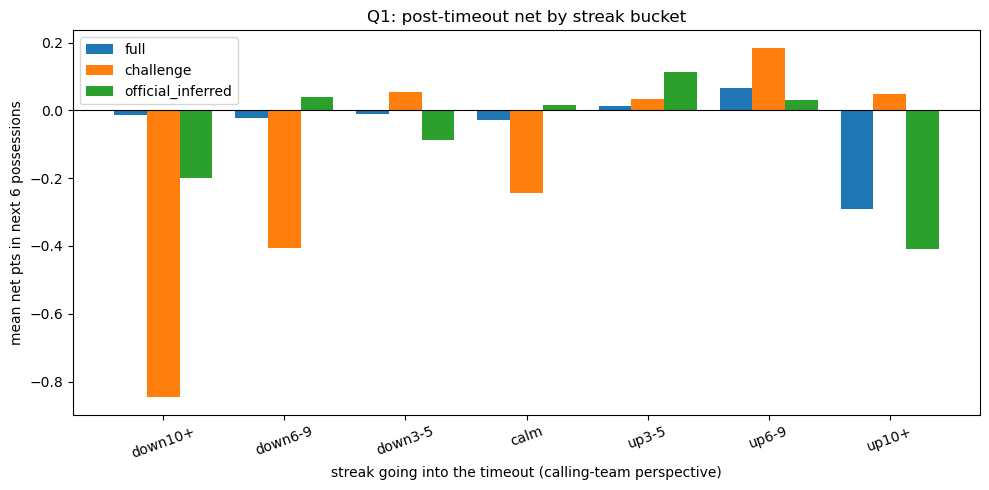

In [14]:
STREAK_ORDER = ["down10+", "down6-9", "down3-5", "calm", "up3-5", "up6-9", "up10+"]
summary_streak = (
    summarize_pre_post(events, ["timeout_subtype", "streak_bucket"])
    .with_columns(pl.col("streak_bucket").cast(pl.Enum(STREAK_ORDER)))
    .sort("timeout_subtype", "streak_bucket")
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(STREAK_ORDER))
width = 0.27
for i, sub in enumerate(["full", "challenge", "official_inferred"]):
    rows = summary_streak.filter(pl.col("timeout_subtype") == sub)
    means = [rows.filter(pl.col("streak_bucket") == b)["net_post_mean"].to_list() for b in STREAK_ORDER]
    means = [m[0] if m else np.nan for m in means]
    ax.bar(x + (i - 1) * width, means, width=width, label=sub)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(STREAK_ORDER, rotation=20)
ax.set_xlabel("streak going into the timeout (calling-team perspective)")
ax.set_ylabel("mean net pts in next 6 possessions")
ax.set_title("Q1: post-timeout net by streak bucket")
ax.legend()
plt.tight_layout()
plt.show()

## Q2. Short-term Momentum (PPP)

Same slices as Q1 but the metric is `ppp_for_pre` and `ppp_for_post` — calling-team-only points per possession.

`excess_vs_baseline` = mean(`ppp_for_post − calling_team_ppp`). Positive = post-window outperformed the calling team's season-long PPP.

In [15]:
summarize_pre_post(events, ["timeout_subtype"], metric="ppp")

timeout_subtype,n,ppp_for_pre_mean,ppp_for_post_mean,delta_mean,delta_std,excess_vs_baseline,t_stat,p_value
cat,u32,f64,f64,f64,f64,f64,f64,f64
"""challenge""",1396,1.219198,1.123149,-0.096048,0.958203,-0.021128,3.681369,0.000236
"""full""",74236,0.880233,1.145539,0.265306,0.955616,0.006733,-75.564627,0.0
"""official_inferred""",14538,1.139175,1.152703,0.013528,0.953755,0.013404,-1.697387,0.089634


In [16]:
summarize_pre_post(events, ["timeout_subtype", "is_home_calling"], metric="ppp")

timeout_subtype,is_home_calling,n,ppp_for_pre_mean,ppp_for_post_mean,delta_mean,delta_std,excess_vs_baseline,t_stat,p_value
cat,bool,u32,f64,f64,f64,f64,f64,f64,f64
"""challenge""",false,647,1.20711,1.129572,-0.077537,0.971935,-0.014524,2.012335,0.044394
"""challenge""",true,749,1.22964,1.117601,-0.112038,0.946539,-0.026834,3.15866,0.001617
"""full""",false,37014,0.866776,1.132601,0.265825,0.951133,-0.006356,-53.663507,0.0
"""full""",true,37222,0.893616,1.158405,0.26479,0.960066,0.019749,-53.224031,0.0
"""official_inferred""",false,7172,1.135202,1.142917,0.007715,0.953969,0.003073,-0.678881,0.497224
"""official_inferred""",true,7366,1.143045,1.162232,0.019187,0.953577,0.023463,-1.716374,0.086115


In [17]:
summarize_pre_post(events, ["timeout_subtype", "time_bucket"], metric="ppp")

timeout_subtype,time_bucket,n,ppp_for_pre_mean,ppp_for_post_mean,delta_mean,delta_std,excess_vs_baseline,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64,f64
"""challenge""","""OT""",30,1.0,0.9,-0.1,0.893356,-0.240263,0.583088,0.563046
"""challenge""","""Q1""",150,1.271111,1.097778,-0.173333,0.959835,-0.045911,2.1447,0.032785
"""challenge""","""Q2""",331,1.222558,1.208459,-0.014099,1.022213,0.061996,0.263097,0.792558
"""challenge""","""Q3""",356,1.208801,1.06367,-0.145131,0.943724,-0.082193,2.748098,0.006147
"""challenge""","""Q4_clutch""",433,1.246343,1.126828,-0.119515,0.927496,-0.016028,2.597298,0.009557
…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""Q1""",5209,1.12888,1.155692,0.026813,0.962176,0.016584,-2.01521,0.043908
"""official_inferred""","""Q2""",3623,1.126323,1.160824,0.034502,0.940271,0.021181,-2.178411,0.029408
"""official_inferred""","""Q3""",3647,1.166804,1.140024,-0.02678,0.958762,0.000508,1.67924,0.093148


In [18]:
summarize_pre_post(events, ["timeout_subtype", "streak_bucket"], metric="ppp")

timeout_subtype,streak_bucket,n,ppp_for_pre_mean,ppp_for_post_mean,delta_mean,delta_std,excess_vs_baseline,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64,f64
"""challenge""","""calm""",623,1.140717,1.11771,-0.023007,0.879334,-0.025789,0.650709,0.515355
"""challenge""","""down10+""",13,0.0,1.051282,1.051282,0.705089,-0.083406,-5.375845,0.000166
"""challenge""","""down3-5""",220,0.781818,1.11553,0.333712,0.98184,-0.031321,-5.231552,2.6222e-7
"""challenge""","""down6-9""",54,0.111111,0.932099,0.820988,0.723122,-0.20909,-8.868154,5.0253e-13
"""challenge""","""up10+""",21,1.873016,0.904762,-0.968254,0.999471,-0.237316,4.747405,0.000027
…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,1.014459,1.1469,0.132441,0.92615,0.007892,-9.350423,1.0938e-20
"""official_inferred""","""down6-9""",1146,0.375218,1.158813,0.783595,0.834423,0.021837,-31.069688,4.9741e-173
"""official_inferred""","""up10+""",39,1.854701,1.034188,-0.820513,1.002471,-0.105206,5.389214,7.6819e-7


## Q3. Long-term — WP Added

Trains a logistic-regression WP model on possession-start snapshots, then for each timeout predicts the calling team's win probability at the start of the pre-window and the end of the post-window. `wp_added_calling = wp_post_calling − wp_pre_calling`.

Holdout split is by *game* (not row), so train and test never share a game.

**Caveat.** This is a window-based delta, not a counterfactual estimate. It tells us how the calling team's win probability moved across the ±6-possession window — which captures the timeout's effect plus the regression to the mean that would have happened anyway. Compare across subtypes / contexts (relative differences are robust); raw values absorb the natural rebound.

In [19]:
X_train, X_test, y_train, y_test, snaps = build_wp_dataset(memo, sample_n=600_000, seed=42)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"snaps:   {snaps.shape}")

X_train: (480045, 10)
X_test:  (119955, 10)
snaps:   (1480697, 20)


In [20]:
model = train_wp_model(X_train, y_train)
metrics = evaluate_wp_model(model, X_test, y_test)
print(metrics)

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'n_test': 119955, 'log_loss': 0.4831212531837786, 'brier': 0.1609750017012607, 'auc': 0.8443630595195263, 'base_rate_home_won': 0.5333249968738277}


In [21]:
coef_table(model)

,feature,coef,abs_coef
0,score_margin,1.617189,1.617189
1,wpct_diff,0.390130,0.390130
2,home_wpct,0.304220,0.304220
3,away_wpct,-0.246520,0.246520
4,is_playoff,-0.049134,0.049134
5,poss_is_home,0.026013,0.026013
6,streak_home,-0.023165,0.023165
7,period,-0.017547,0.017547
8,is_clutch,-0.013819,0.013819
9,seconds_remaining,0.002234,0.002234


In [22]:
events_wp = compute_wp_added(events, snaps, model, window=WINDOW)
print(f"events_wp: {events_wp.shape}")
print("non-null wp_added_calling:", events_wp["wp_added_calling"].drop_nulls().len())

events_wp: (90170, 48)
non-null wp_added_calling: 90170


In [23]:
summarize_wp_added(events_wp)

n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
u32,f64,f64,f64,f64,f64,f64
90170,0.506042,0.472161,-0.033881,0.098576,-103.209147,0.0


In [24]:
summarize_wp_added(events_wp, ["timeout_subtype"])

timeout_subtype,n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
cat,u32,f64,f64,f64,f64,f64,f64
"""challenge""",1396,0.529055,0.544656,0.015601,0.098922,5.892457,4.7635e-9
"""full""",74236,0.506446,0.467472,-0.038974,0.098095,-108.251359,0.0
"""official_inferred""",14538,0.501772,0.489145,-0.012627,0.096827,-15.724104,2.9488e-55


In [25]:
summarize_wp_added(events_wp, ["timeout_subtype", "is_home_calling"])

timeout_subtype,is_home_calling,n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
cat,bool,u32,f64,f64,f64,f64,f64,f64
"""challenge""",false,647,0.474885,0.488104,0.013219,0.104582,3.215163,0.001369
"""challenge""",true,749,0.575848,0.593506,0.017658,0.09378,5.153122,3.2810e-7
"""full""",false,37014,0.452196,0.411422,-0.040774,0.096865,-80.984551,0.0
"""full""",true,37222,0.560392,0.523209,-0.037183,0.099272,-72.264152,0.0
"""official_inferred""",false,7172,0.445811,0.432091,-0.01372,0.095805,-12.128088,1.5941e-33
"""official_inferred""",true,7366,0.556258,0.544695,-0.011563,0.097806,-10.146675,4.9308e-24


In [26]:
summarize_wp_added(events_wp, ["timeout_subtype", "IsPlayoff"])

timeout_subtype,IsPlayoff,n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
cat,bool,u32,f64,f64,f64,f64,f64,f64
"""challenge""",false,1311,0.529345,0.544426,0.015082,0.098821,5.525846,3.9516e-8
"""challenge""",true,85,0.524588,0.548198,0.02361,0.100723,2.16106,0.033538
"""full""",false,69939,0.506421,0.467487,-0.038934,0.097935,-105.135887,0.0
"""full""",true,4297,0.50684,0.467219,-0.039621,0.100672,-25.79897,1.4124e-136
"""official_inferred""",false,13787,0.502347,0.489712,-0.012635,0.096505,-15.372714,6.8488e-53
"""official_inferred""",true,751,0.491211,0.47872,-0.01249,0.102623,-3.33543,0.000894


In [27]:
summarize_wp_added(events_wp, ["timeout_subtype", "time_bucket"])

timeout_subtype,time_bucket,n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64
"""challenge""","""OT""",30,0.536314,0.54233,0.006017,0.136508,0.241406,0.810939
"""challenge""","""Q1""",150,0.521299,0.540608,0.019309,0.108611,2.177357,0.031028
"""challenge""","""Q2""",331,0.549736,0.576355,0.026619,0.096476,5.019739,8.4803e-7
"""challenge""","""Q3""",356,0.550164,0.556052,0.005888,0.086455,1.285089,0.199599
"""challenge""","""Q4_clutch""",433,0.5018,0.51779,0.015991,0.107989,3.081245,0.002193
…,…,…,…,…,…,…,…,…
"""official_inferred""","""Q1""",5209,0.501196,0.486021,-0.015175,0.106713,-10.26323,1.7629e-24
"""official_inferred""","""Q2""",3623,0.500793,0.490663,-0.01013,0.095532,-6.382713,1.9601e-10
"""official_inferred""","""Q3""",3647,0.503425,0.490077,-0.013349,0.090552,-8.902403,8.4452e-19


In [28]:
summarize_wp_added(events_wp, ["timeout_subtype", "streak_bucket"])

timeout_subtype,streak_bucket,n,wp_pre_mean,wp_post_mean,wp_added_mean,wp_added_std,t_stat,p_value
cat,str,u32,f64,f64,f64,f64,f64,f64
"""challenge""","""calm""",623,0.504485,0.510375,0.00589,0.082036,1.792057,0.07361
"""challenge""","""down10+""",13,0.610683,0.498519,-0.112164,0.092289,-4.38203,0.000893
"""challenge""","""down3-5""",220,0.578418,0.542135,-0.036283,0.077448,-6.948698,4.1622e-11
"""challenge""","""down6-9""",54,0.551377,0.440308,-0.111069,0.094345,-8.651116,1.0353e-11
"""challenge""","""up10+""",21,0.533482,0.631521,0.098039,0.109407,4.106429,0.000549
…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,0.498017,0.451044,-0.046973,0.084895,-36.425995,1.1182e-253
"""official_inferred""","""down6-9""",1146,0.480518,0.378014,-0.102504,0.091287,-38.012528,3.5931e-205
"""official_inferred""","""up10+""",39,0.585159,0.705012,0.119853,0.101844,7.349336,8.3234e-9


### Q3 visualization — WP added by streak bucket

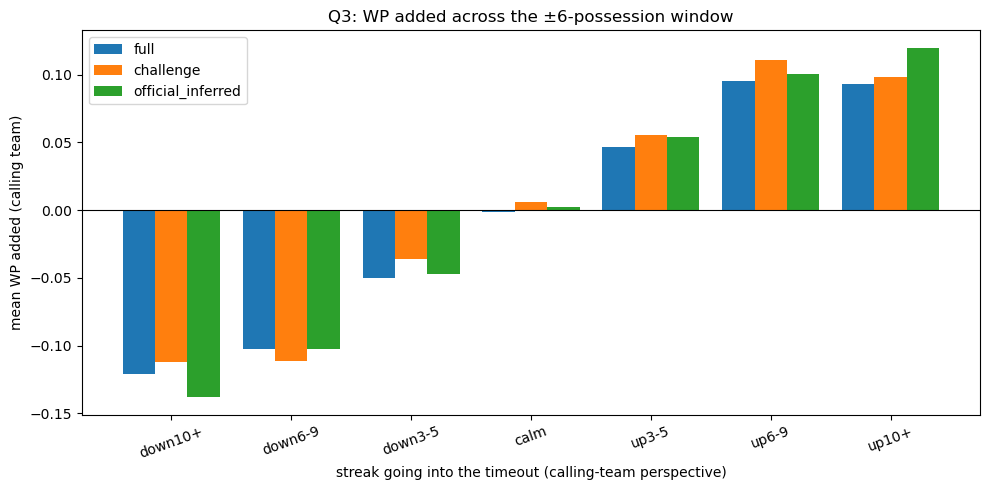

In [29]:
summary_wp_streak = (
    summarize_wp_added(events_wp, ["timeout_subtype", "streak_bucket"])
    .with_columns(pl.col("streak_bucket").cast(pl.Enum(STREAK_ORDER)))
    .sort("timeout_subtype", "streak_bucket")
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(STREAK_ORDER))
width = 0.27
for i, sub in enumerate(["full", "challenge", "official_inferred"]):
    rows = summary_wp_streak.filter(pl.col("timeout_subtype") == sub)
    means = [rows.filter(pl.col("streak_bucket") == b)["wp_added_mean"].to_list() for b in STREAK_ORDER]
    means = [m[0] if m else np.nan for m in means]
    ax.bar(x + (i - 1) * width, means, width=width, label=sub)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(STREAK_ORDER, rotation=20)
ax.set_xlabel("streak going into the timeout (calling-team perspective)")
ax.set_ylabel("mean WP added (calling team)")
ax.set_title("Q3: WP added across the ±6-possession window")
ax.legend()
plt.tight_layout()
plt.show()

## Sandbox

Use this section to slice events further or try alternative window sizes:

```python
events_w4 = attach_baselines(build_timeout_events(memo, window=4), team_ppp, h2h, window=4)
summarize_pre_post(events_w4, ['timeout_subtype'])
```